# Calculate r-Value
* Contributor: Franz Roters
* DAMASK version: 3.1.0
* Prerequisites (data): DADF5 results file from MSC.Marc with plastic deformation gradient ('F_p')

## Approaches to r-value calculations.
There are several options to calculate the strains that are used to calculate the r-value, the following are considered here:
1. Calculate the plastic strain $\boldsymbol{\epsilon}_\mathrm{p}$ on each point before averaging
1. Average the deformation gradient $\mathbf{F}$ and calculate the strain from this average
1. Calculate the right plastic stretch $\mathbf{U}_\mathrm{p}$, average it, and calculate the strain from this average

Notes:
- Averaging deformation gradients or stretches is preferred over averaging strains.
- Differences between the use of $\mathbf{F}$ and $\mathbf{U}_\mathrm{p}$ are expected to be small because the elastic strains are small.
- Since $\mathbf{F}_\mathrm{p}$ contains rotation, averaging it or using strains based on $\mathbf{V}_\mathrm{p}$ leads to bogus results (not shown here).

In [1]:
%matplotlib inline

In [2]:
import damask
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True # set to False if Latex is not installed

In [3]:
# adjust to your situation, file needs to exist
result_file = 'r-value_Marc/r-value_texture.hdf5'

In [4]:
result = damask.Result(result_file)
result.add_strain('F_p','U')
result.add_stretch_tensor('F_p',t='U')

In [5]:
# option 1, r-value from local plastic strain
epsilon_avegered = np.array([np.average(eps,0) for eps in result.get('epsilon_U^0.0(F_p)').values()])
r_eps_p = epsilon_avegered[:,1,1]/epsilon_avegered[:,2,2] 

# option 2, r-value from averaged F
F_avg = np.array([np.average(F,0) for F in result.get('F').values()])
epsilon_avg = damask.mechanics.strain(F_avg,t='U',m=0.0)
r_F = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]

# option 3, r-value from averaged U_p (F_p without rotational part)
U_p_avg = np.array([np.average(U_p,0) for U_p in result.get('U(F_p)').values()])
epsilon_F_p_avg = damask.mechanics.strain(U_p_avg,t='U',m=0.0) 
assert np.allclose(epsilon_F_p_avg, damask.mechanics.strain(U_p_avg,t='V',m=0.0)) # no rotational part, so t='V' must be equivalent
r_F_p = epsilon_F_p_avg[:,1,1]/epsilon_F_p_avg[:,2,2]

epsilon_F_p_vM_avg = damask.mechanics.equivalent_strain_Mises(epsilon_F_p_avg)

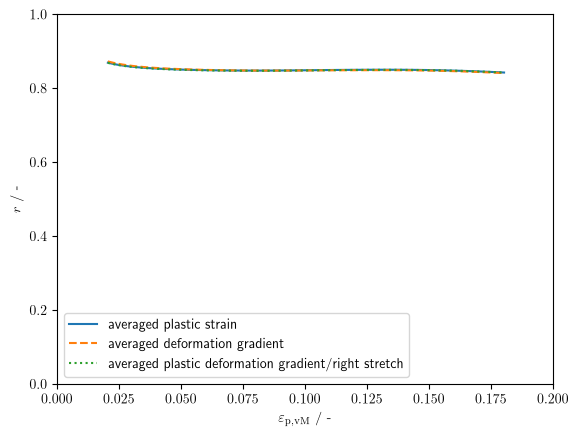

In [6]:
fig, ax = plt.subplots()
ax.plot(epsilon_F_p_vM_avg[10:],r_eps_p[10:],label='averaged plastic strain')
ax.plot(epsilon_F_p_vM_avg[10:],r_F[10:],label='averaged deformation gradient',linestyle='--')
ax.plot(epsilon_F_p_vM_avg[10:],r_F_p[10:],label='averaged plastic deformation gradient/right stretch',linestyle=':')

ax.set_ylabel(r'$r$ / -')
ax.set_xlabel(r'$\varepsilon_\mathrm{p,vM}$ / -')
ax.set_xlim([0, 0.2])
ax.set_ylim([0, 1])
ax.legend()
plt.show()